# GPTQ 參數影響分析

分析 GPTQ 量化參數對三個優化目標的影響：
- `accuracy_change` (準確率變化) - 越高越好
- `gpu_peak_change` (GPU 峰值變化) - 越低越好
- `latency_change` (延遲變化) - 越低越好

## 數據來源
- `results/optimization/` - Optuna/Random 優化器實驗
- `results/llm_optimization/` - LLM 多智能體優化器實驗

In [1]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# 設置顯示選項
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# 設置繪圖風格與中文字體
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

sns.set_style('whitegrid')
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'Noto Serif CJK JP', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題

# 確認字體設置
print(f"使用字體: {plt.rcParams['font.sans-serif'][0]}")

使用字體: Noto Sans CJK JP


## 數據載入

In [2]:
# GPTQ 預設參數 (來自 tmp/method/quantization.py 的 GPTQConfig)
GPTQ_DEFAULTS = {
    'bits': 4,
    'group_size': 128,
    'calib_num': 256,
    'damp_percent': 0.05,
    'damp_auto_increment': 0.01,
    'desc_act': True,
    'act_group_aware': False,
    'static_groups': False,
    'sym': True,
    'true_sequential': True,
    'lm_head': False,
    'mse': 0.0,
    'rotation': None,
}

def load_gptq_trials(base_path: Path) -> list:
    """從指定目錄載入所有 GPTQ trials"""
    gptq_trials = []
    
    for trial_file in base_path.glob('*/all_trials.json'):
        experiment_name = trial_file.parent.name
        
        with open(trial_file, 'r') as f:
            data = json.load(f)
        
        for i, trial in enumerate(data.get('trials', [])):
            config = trial.get('config', {})
            
            # 只保留 GPTQ method
            if config.get('method') != 'gptq':
                continue
            
            # 只保留完成的 trials
            if trial.get('status') != 'completed':
                continue
            
            objectives = trial.get('objectives', {})
            
            # 使用預設值填充缺失的參數
            trial_record = {
                'experiment': experiment_name,
                'trial_index': i,
            }
            
            # GPTQ 參數 - 使用預設值填充 None
            for param, default_val in GPTQ_DEFAULTS.items():
                val = config.get(param)
                trial_record[param] = val if val is not None else default_val
            
            # 優化目標
            trial_record['accuracy_change'] = objectives.get('accuracy_change')
            trial_record['gpu_peak_change'] = objectives.get('gpu_peak_change')
            trial_record['latency_change'] = objectives.get('latency_change')
            
            # 其他資訊
            trial_record['satisfies_constraints'] = trial.get('satisfies_constraints')
            trial_record['satisfies_targets'] = trial.get('satisfies_targets')
            trial_record['violation_score'] = trial.get('violation_score')
            
            gptq_trials.append(trial_record)
    
    return gptq_trials

# 載入數據
results_path = Path('.')
optimization_trials = load_gptq_trials(results_path / 'optimization')
llm_optimization_trials = load_gptq_trials(results_path / 'llm_optimization')

# 添加來源標記
for t in optimization_trials:
    t['source'] = 'optuna/random'
for t in llm_optimization_trials:
    t['source'] = 'llm_agent'

# 合併數據
all_trials = optimization_trials + llm_optimization_trials
df = pd.DataFrame(all_trials)

print(f"載入完成:")
print(f"  - Optuna/Random 優化器: {len(optimization_trials)} GPTQ trials")
print(f"  - LLM 智能體優化器: {len(llm_optimization_trials)} GPTQ trials")
print(f"  - 總計: {len(df)} GPTQ trials")
print(f"\n缺失參數已使用 GPTQConfig 預設值填充")

載入完成:
  - Optuna/Random 優化器: 73 GPTQ trials
  - LLM 智能體優化器: 46 GPTQ trials
  - 總計: 119 GPTQ trials

缺失參數已使用 GPTQConfig 預設值填充


## 數據概覽

In [3]:
# GPTQ 參數列表
gptq_params = ['bits', 'group_size', 'calib_num', 'desc_act', 'sym', 
               'damp_percent', 'damp_auto_increment', 'act_group_aware', 
               'static_groups', 'true_sequential', 'lm_head', 'mse', 'rotation']

objective_cols = ['accuracy_change', 'gpu_peak_change', 'latency_change']

print("=" * 60)
print("GPTQ 參數值分布")
print("=" * 60)

for param in gptq_params:
    if param in df.columns:
        unique_values = df[param].dropna().unique()
        value_counts = df[param].value_counts(dropna=False)
        print(f"\n{param}:")
        print(f"  唯一值: {sorted([v for v in unique_values if pd.notna(v)])}")
        print(f"  分布: {value_counts.to_dict()}")

GPTQ 參數值分布

bits:
  唯一值: [np.int64(2), np.int64(3), np.int64(4), np.int64(8)]
  分布: {4: 59, 8: 26, 3: 20, 2: 14}

group_size:
  唯一值: [np.int64(-1), np.int64(16), np.int64(32), np.int64(64), np.int64(128)]
  分布: {128: 42, 32: 39, 64: 17, -1: 11, 16: 10}

calib_num:
  唯一值: [np.int64(256)]
  分布: {256: 119}

desc_act:
  唯一值: [np.False_, np.True_]
  分布: {False: 64, True: 55}

sym:
  唯一值: [np.False_, np.True_]
  分布: {True: 61, False: 58}

damp_percent:
  唯一值: [np.float64(0.001), np.float64(0.005), np.float64(0.01), np.float64(0.03), np.float64(0.05)]
  分布: {0.01: 38, 0.005: 27, 0.001: 22, 0.03: 16, 0.05: 16}

damp_auto_increment:
  唯一值: [np.float64(0.001), np.float64(0.005), np.float64(0.01), np.float64(0.03), np.float64(0.05)]
  分布: {0.005: 47, 0.01: 24, 0.001: 21, 0.03: 16, 0.05: 11}

act_group_aware:
  唯一值: [np.False_, np.True_]
  分布: {False: 89, True: 30}

static_groups:
  唯一值: [np.False_, np.True_]
  分布: {False: 68, True: 51}

true_sequential:
  唯一值: [np.False_, np.True_]
  分布: {True: 6

In [4]:
print("\n" + "=" * 60)
print("優化目標統計")
print("=" * 60)

for obj in objective_cols:
    if obj in df.columns:
        values = df[obj].dropna()
        print(f"\n{obj}:")
        print(f"  範圍: [{values.min():.4f}, {values.max():.4f}]")
        print(f"  平均: {values.mean():.4f}")
        print(f"  中位數: {values.median():.4f}")
        print(f"  標準差: {values.std():.4f}")


優化目標統計

accuracy_change:
  範圍: [-1.0000, 0.6800]
  平均: -0.2655
  中位數: -0.1864
  標準差: 0.3567

gpu_peak_change:
  範圍: [-0.6424, -0.2912]
  平均: -0.5022
  中位數: -0.5354
  標準差: 0.0924

latency_change:
  範圍: [-0.3326, 12.4887]
  平均: 1.5183
  中位數: 0.5310
  標準差: 2.3128


## 主要分析表格 (帶顏色漸層)

顏色規則：
- `accuracy_change`: 綠色(高=好) → 紅色(低=差)
- `gpu_peak_change`: 綠色(低=好) → 紅色(高=差)
- `latency_change`: 綠色(低=好) → 紅色(高=差)

In [5]:
def style_dataframe(df_display):
    """為 DataFrame 添加顏色漸層樣式"""
    
    df_styled = df_display.copy()
    
    def color_accuracy(val):
        """accuracy_change: 越高越好 (綠色=高, 紅色=低)"""
        if pd.isna(val):
            return ''
        col_data = df_display['accuracy_change'].dropna()
        if col_data.max() == col_data.min():
            return 'background-color: rgba(255, 255, 0, 0.5)'
        norm = (val - col_data.min()) / (col_data.max() - col_data.min())
        r = int(255 * (1 - norm))
        g = int(255 * norm)
        return f'background-color: rgba({r}, {g}, 0, 0.6)'
    
    def color_minimize(val, col_name):
        """gpu_peak_change, latency_change: 越低越好 (綠色=低, 紅色=高)"""
        if pd.isna(val):
            return ''
        col_data = df_display[col_name].dropna()
        if col_data.max() == col_data.min():
            return 'background-color: rgba(255, 255, 0, 0.5)'
        norm = (val - col_data.min()) / (col_data.max() - col_data.min())
        r = int(255 * norm)
        g = int(255 * (1 - norm))
        return f'background-color: rgba({r}, {g}, 0, 0.6)'
    
    # 格式化函數
    def fmt_int(x):
        return f'{int(x)}' if pd.notna(x) else ''
    
    def fmt_3f(x):
        return f'{x:.3f}' if pd.notna(x) else ''
    
    def fmt_1f(x):
        return f'{x:.1f}' if pd.notna(x) else ''
    
    def fmt_4f(x):
        return f'{x:.4f}' if pd.notna(x) else ''
    
    # 創建樣式
    styled = df_styled.style
    
    if 'accuracy_change' in df_styled.columns:
        styled = styled.map(color_accuracy, subset=['accuracy_change'])
    
    if 'gpu_peak_change' in df_styled.columns:
        styled = styled.map(lambda x: color_minimize(x, 'gpu_peak_change'), subset=['gpu_peak_change'])
    
    if 'latency_change' in df_styled.columns:
        styled = styled.map(lambda x: color_minimize(x, 'latency_change'), subset=['latency_change'])
    
    # 建立格式字典
    format_dict = {}
    for col in df_styled.columns:
        if col in ['bits', 'group_size', 'calib_num']:
            format_dict[col] = fmt_int
        elif col in ['damp_percent', 'damp_auto_increment']:
            format_dict[col] = fmt_3f
        elif col in ['mse']:
            format_dict[col] = fmt_1f
        elif col in ['accuracy_change', 'gpu_peak_change', 'latency_change', 'violation_score']:
            format_dict[col] = fmt_4f
    
    styled = styled.format(format_dict)
    
    return styled

In [6]:
# 選擇顯示的欄位
display_cols = ['bits', 'group_size', 'desc_act', 'sym', 'damp_percent', 
                'damp_auto_increment', 'mse', 'act_group_aware', 'static_groups',
                'true_sequential', 'accuracy_change', 'gpu_peak_change', 'latency_change',
                ]

# 過濾存在的欄位
display_cols = [c for c in display_cols if c in df.columns]

df_display = df[display_cols].copy()

# 按 accuracy_change 降序排列
df_display = df_display.sort_values('accuracy_change', ascending=False).reset_index(drop=True)

print(f"所有 GPTQ Trials ({len(df_display)} 筆)")
print("顏色說明: 綠色=好, 紅色=差")
print("="*80)
display(style_dataframe(df_display))

所有 GPTQ Trials (119 筆)
顏色說明: 綠色=好, 紅色=差


,bits,group_size,desc_act,sym,damp_percent,damp_auto_increment,mse,act_group_aware,static_groups,true_sequential,accuracy_change,gpu_peak_change,latency_change
0,3,32,True,False,0.005,0.050,0.2,False,True,False,0.6800,-0.5454,7.0039
1,3,32,True,False,0.005,0.030,0.2,False,True,False,0.6000,-0.5451,12.4887
2,3,64,True,True,0.005,0.001,0.0,False,True,False,0.4400,-0.5598,2.8623
3,8,16,True,False,0.001,0.010,0.0,False,True,False,0.3600,-0.2926,0.9209
4,4,32,True,True,0.010,0.005,0.1,False,True,False,0.3200,-0.5208,3.4976
5,3,32,False,True,0.005,0.050,0.0,False,False,True,0.2800,-0.5441,1.6212
6,3,32,False,True,0.005,0.050,0.0,False,False,True,0.2800,-0.5441,1.6348
7,3,32,False,True,0.005,0.005,0.0,True,True,True,0.2400,-0.5295,9.9513
8,4,32,False,True,0.030,0.001,0.0,False,True,True,0.2000,-0.5183,1.0284
9,4,32,False,True,0.030,0.001,0.0,False,True,True,0.2000,-0.5183,1.0313


## 按參數分組的統計分析

In [7]:
def analyze_by_parameter(df, param_name, objectives):
    """按參數值分組計算統計"""
    if param_name not in df.columns:
        return None
    
    # 分組統計
    grouped = df.groupby(param_name)[objectives].agg(['mean', 'std', 'min', 'max', 'count'])
    
    # 扁平化多層索引
    grouped.columns = ['_'.join(col).strip() for col in grouped.columns.values]
    grouped = grouped.reset_index()
    
    return grouped

def style_summary_table(df_summary, objectives):
    """為彙總表添加樣式"""
    styled = df_summary.style
    
    # 格式化函數
    def fmt_4f(x):
        return f'{x:.4f}' if pd.notna(x) else ''
    
    def fmt_int(x):
        return f'{int(x)}' if pd.notna(x) else ''
    
    # 為平均值欄位添加顏色
    if 'accuracy_change_mean' in df_summary.columns:
        def color_acc_mean(val):
            if pd.isna(val):
                return ''
            col_data = df_summary['accuracy_change_mean'].dropna()
            if col_data.max() == col_data.min():
                return ''
            norm = (val - col_data.min()) / (col_data.max() - col_data.min())
            r = int(255 * (1 - norm))
            g = int(255 * norm)
            return f'background-color: rgba({r}, {g}, 0, 0.5)'
        styled = styled.map(color_acc_mean, subset=['accuracy_change_mean'])
    
    for obj in ['gpu_peak_change', 'latency_change']:
        col = f'{obj}_mean'
        if col in df_summary.columns:
            def color_min_mean(val, column=col):
                if pd.isna(val):
                    return ''
                col_data = df_summary[column].dropna()
                if col_data.max() == col_data.min():
                    return ''
                norm = (val - col_data.min()) / (col_data.max() - col_data.min())
                r = int(255 * norm)
                g = int(255 * (1 - norm))
                return f'background-color: rgba({r}, {g}, 0, 0.5)'
            styled = styled.map(lambda x, c=col: color_min_mean(x, c), subset=[col])
    
    # 建立格式字典
    format_dict = {}
    for obj in objectives:
        for stat in ['mean', 'std', 'min', 'max']:
            col = f'{obj}_{stat}'
            if col in df_summary.columns:
                format_dict[col] = fmt_4f
        count_col = f'{obj}_count'
        if count_col in df_summary.columns:
            format_dict[count_col] = fmt_int
    
    # 第一欄（參數名）的格式化
    first_col = df_summary.columns[0]
    if df_summary[first_col].dtype in ['float64', 'float32']:
        if first_col in ['bits', 'group_size', 'calib_num']:
            format_dict[first_col] = fmt_int
        elif first_col in ['damp_percent', 'damp_auto_increment']:
            format_dict[first_col] = lambda x: f'{x:.3f}' if pd.notna(x) else ''
        elif first_col == 'mse':
            format_dict[first_col] = lambda x: f'{x:.1f}' if pd.notna(x) else ''
    
    styled = styled.format(format_dict)
    
    return styled

In [8]:
# 分析關鍵參數
key_params = ['bits', 'group_size', 'desc_act', 'sym', 'mse', 'damp_percent']

for param in key_params:
    summary = analyze_by_parameter(df, param, objective_cols)
    if summary is not None and len(summary) > 0:
        print(f"\n{'='*60}")
        print(f"按 {param} 分組的統計")
        print(f"{'='*60}")
        display(style_summary_table(summary, objective_cols))


按 bits 分組的統計


,bits,accuracy_change_mean,accuracy_change_std,accuracy_change_min,accuracy_change_max,accuracy_change_count,gpu_peak_change_mean,gpu_peak_change_std,gpu_peak_change_min,gpu_peak_change_max,gpu_peak_change_count,latency_change_mean,latency_change_std,latency_change_min,latency_change_max,latency_change_count
0,2,-0.6947,0.3208,-1.0000,-0.0400,14,-0.6204,0.0159,-0.6424,-0.5902,14,2.3934,1.5056,1.1281,5.2005,14
1,3,-0.1727,0.4942,-1.0000,0.6800,20,-0.5524,0.0158,-0.5821,-0.5264,20,4.3105,3.9307,0.3967,12.4887,20
2,4,-0.2225,0.2605,-0.9600,0.3200,59,-0.5288,0.0135,-0.5501,-0.4871,59,0.6069,1.0043,-0.3326,3.8569,59
3,8,-0.2033,0.2927,-0.9600,0.3600,26,-0.3398,0.0245,-0.3650,-0.2912,26,0.9673,1.0220,0.2793,3.5231,26



按 group_size 分組的統計


,group_size,accuracy_change_mean,accuracy_change_std,accuracy_change_min,accuracy_change_max,accuracy_change_count,gpu_peak_change_mean,gpu_peak_change_std,gpu_peak_change_min,gpu_peak_change_max,gpu_peak_change_count,latency_change_mean,latency_change_std,latency_change_min,latency_change_max,latency_change_count
0,-1,-0.2881,0.3345,-0.9831,0.0508,11,-0.4754,0.1095,-0.6424,-0.3641,11,0.3017,0.4027,-0.1662,1.2381,11
1,16,-0.3877,0.4736,-0.9600,0.3600,10,-0.4341,0.1281,-0.5917,-0.2912,10,1.9210,1.3068,0.3804,3.5231,10
2,32,-0.2383,0.4321,-0.9600,0.6800,39,-0.5100,0.0854,-0.6172,-0.3277,39,2.3461,2.9281,-0.0845,12.4887,39
3,64,-0.3882,0.4186,-1.0000,0.4400,17,-0.5080,0.0972,-0.6290,-0.3454,17,2.1693,3.1189,-0.0405,12.2367,17
4,128,-0.2060,0.1842,-0.9661,0.0800,42,-0.5159,0.0774,-0.6373,-0.3509,42,0.7088,1.1413,-0.3326,5.2005,42



按 desc_act 分組的統計


...

,sym,accuracy_change_mean,accuracy_change_std,accuracy_change_min,accuracy_change_max,accuracy_change_count,gpu_peak_change_mean,gpu_peak_change_std,gpu_peak_change_min,gpu_peak_change_max,gpu_peak_change_count,latency_change_mean,latency_change_std,latency_change_min,latency_change_max,latency_change_count
0,False,-0.3015,0.3737,-1.0000,0.6800,58,-0.5067,0.0876,-0.6424,-0.2926,58,1.3498,2.4123,-0.1960,12.4887,58
1,True,-0.2313,0.3394,-1.0000,0.4400,61,-0.4980,0.0972,-0.6373,-0.2912,61,1.6785,2.2222,-0.3326,12.2367,61



按 mse 分組的統計


,mse,accuracy_change_mean,accuracy_change_std,accuracy_change_min,accuracy_change_max,accuracy_change_count,gpu_peak_change_mean,gpu_peak_change_std,gpu_peak_change_min,gpu_peak_change_max,gpu_peak_change_count,latency_change_mean,latency_change_std,latency_change_min,latency_change_max,latency_change_count
0,0.0,-0.0682,0.2070,-0.5200,0.4400,46,-0.5019,0.0922,-0.6373,-0.2926,46,1.5738,1.7373,0.3908,9.9513,46
1,0.1,-0.5044,0.3558,-1.0000,0.3200,47,-0.4955,0.1030,-0.6365,-0.2912,47,1.7601,2.5354,-0.1169,12.2367,47
2,0.2,-0.1827,0.3235,-0.9831,0.6800,26,-0.5150,0.0721,-0.6424,-0.3471,26,0.9830,2.7518,-0.3326,12.4887,26



按 damp_percent 分組的統計


,damp_percent,accuracy_change_mean,accuracy_change_std,accuracy_change_min,accuracy_change_max,accuracy_change_count,gpu_peak_change_mean,gpu_peak_change_std,gpu_peak_change_min,gpu_peak_change_max,gpu_peak_change_count,latency_change_mean,latency_change_std,latency_change_min,latency_change_max,latency_change_count
0,0.001,-0.1620,0.1716,-0.4400,0.3600,22,-0.4888,0.1092,-0.6364,-0.2926,22,1.1270,1.5297,-0.1169,5.2005,22
1,0.005,-0.1150,0.4016,-0.9661,0.6800,27,-0.5081,0.0752,-0.6365,-0.3566,27,1.9272,3.1516,-0.1960,12.4887,27
2,0.010,-0.4286,0.3809,-1.0000,0.3200,38,-0.4853,0.1040,-0.6277,-0.2912,38,1.7030,2.0525,-0.0976,10.0605,38
3,0.030,-0.2318,0.2597,-0.7797,0.2000,16,-0.5140,0.0678,-0.5821,-0.3454,16,0.5609,0.8105,-0.3326,2.6851,16
4,0.050,-0.3081,0.3576,-0.9831,0.0800,16,-0.5391,0.0820,-0.6424,-0.3534,16,1.8850,2.9673,-0.0451,12.2367,16


## 相關性分析

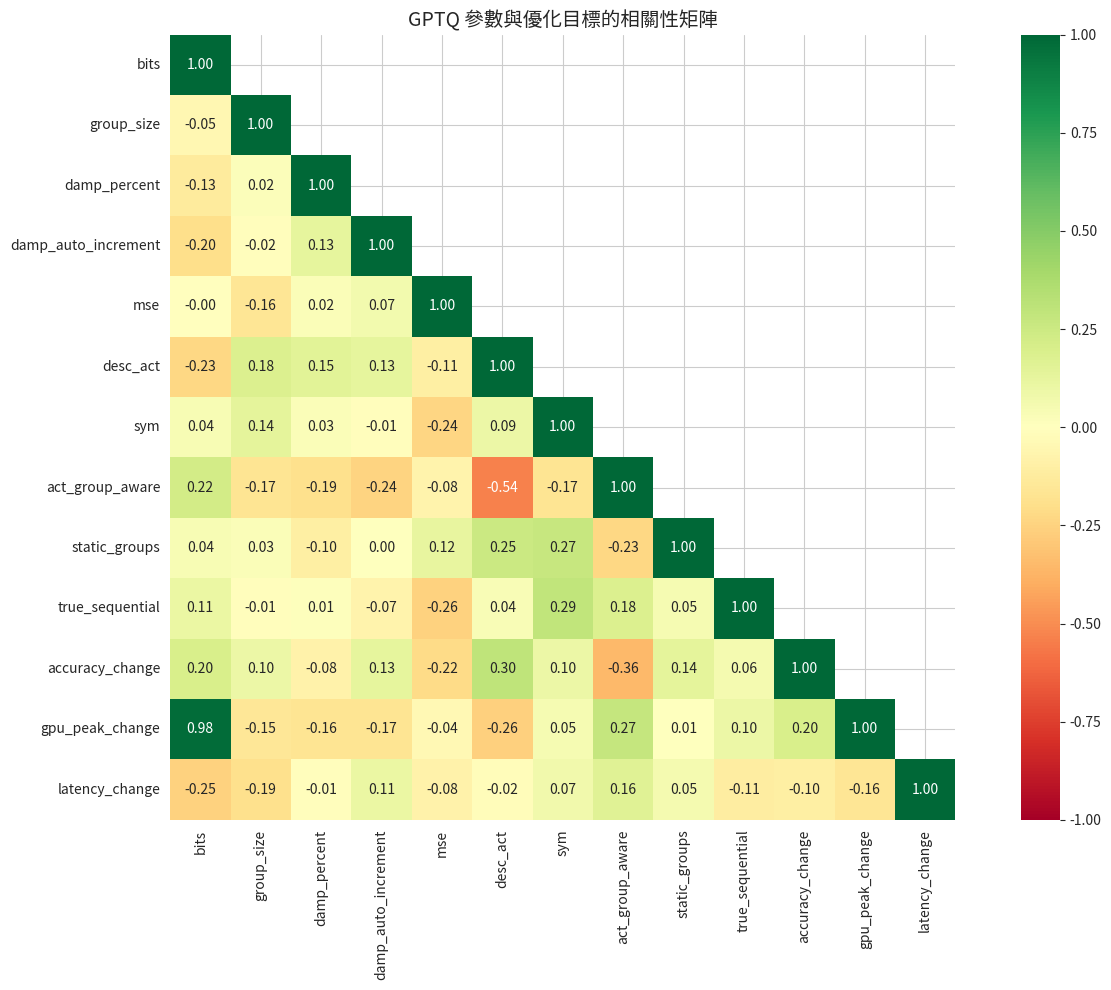

In [9]:
# 選擇數值型參數進行相關性分析
numeric_params = ['bits', 'group_size', 'damp_percent', 'damp_auto_increment', 'mse']
numeric_params = [p for p in numeric_params if p in df.columns]

# 布林參數轉換為數值 (處理 None 值)
bool_params = ['desc_act', 'sym', 'act_group_aware', 'static_groups', 'true_sequential']
df_corr = df.copy()
for bp in bool_params:
    if bp in df_corr.columns:
        # 將 None 轉換為 NaN，然後布林值轉為 0/1
        df_corr[bp] = df_corr[bp].map(lambda x: 1 if x is True else (0 if x is False else np.nan))

all_params = numeric_params + [p for p in bool_params if p in df_corr.columns]
corr_cols = all_params + objective_cols
corr_cols = [c for c in corr_cols if c in df_corr.columns]

# 計算相關係數
corr_matrix = df_corr[corr_cols].corr()

# 繪製熱圖
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            ax=ax)
plt.title('GPTQ 參數與優化目標的相關性矩陣', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# 只顯示參數與目標之間的相關性
print("\n參數與優化目標的相關係數:")
print("="*60)

param_obj_corr = corr_matrix.loc[all_params, objective_cols]

def style_correlation(df_c):
    def color_corr(val):
        if pd.isna(val):
            return ''
        # 使用紅綠漸變，0為黃色
        if val > 0:
            return f'background-color: rgba(0, {int(255*val)}, 0, 0.5)'
        else:
            return f'background-color: rgba({int(255*abs(val))}, 0, 0, 0.5)'
    
    return df_c.style.map(color_corr).format('{:.3f}')

display(style_correlation(param_obj_corr))


參數與優化目標的相關係數:


,accuracy_change,gpu_peak_change,latency_change
bits,0.199,0.979,-0.254
group_size,0.098,-0.149,-0.190
damp_percent,-0.084,-0.165,-0.011
damp_auto_increment,0.131,-0.168,0.107
mse,-0.216,-0.042,-0.079
desc_act,0.298,-0.263,-0.017
sym,0.099,0.048,0.071
act_group_aware,-0.356,0.274,0.163
static_groups,0.138,0.005,0.055
true_sequential,0.058,0.096,-0.110


## 參數重要性分析（單一參數變化影響）

分析當只改變一個參數時，對優化目標的影響程度。這有助於了解每個參數的實際重要性。

In [11]:
def analyze_single_param_impact_detailed(df, params, objectives):
    """
    分析單一參數變化的影響 - 詳細版本
    找出只有一個參數不同的 trial pairs，返回所有配對詳情
    """
    df_valid = df.dropna(subset=objectives).copy().reset_index(drop=True)
    
    all_pairs = []
    
    for target_param in params:
        # 其他參數（用於比對）
        other_params = [p for p in params if p != target_param]
        
        # 按其他參數分組
        groups = df_valid.groupby(other_params, dropna=False)
        
        for group_key, group_df in groups:
            if len(group_df) < 2:
                continue
            
            # 在同一組內，target_param 有不同值的 trials
            unique_vals = group_df[target_param].unique()
            if len(unique_vals) < 2:
                continue
            
            # 計算不同 target_param 值之間的目標差異
            for i, val1 in enumerate(unique_vals):
                for val2 in unique_vals[i+1:]:
                    trials1 = group_df[group_df[target_param] == val1]
                    trials2 = group_df[group_df[target_param] == val2]
                    
                    for idx1, t1 in trials1.iterrows():
                        for idx2, t2 in trials2.iterrows():
                            pair = {
                                'changed_param': target_param,
                                'value_1': val1,
                                'value_2': val2,
                                # Trial 1 的目標值
                                'trial1_acc': t1['accuracy_change'],
                                'trial1_gpu': t1['gpu_peak_change'],
                                'trial1_lat': t1['latency_change'],
                                # Trial 2 的目標值
                                'trial2_acc': t2['accuracy_change'],
                                'trial2_gpu': t2['gpu_peak_change'],
                                'trial2_lat': t2['latency_change'],
                                # 差異（絕對值）
                                'acc_diff': abs(t2['accuracy_change'] - t1['accuracy_change']),
                                'gpu_diff': abs(t2['gpu_peak_change'] - t1['gpu_peak_change']),
                                'lat_diff': abs(t2['latency_change'] - t1['latency_change']),
                                # 差異（有方向）
                                'acc_delta': t2['accuracy_change'] - t1['accuracy_change'],
                                'gpu_delta': t2['gpu_peak_change'] - t1['gpu_peak_change'],
                                'lat_delta': t2['latency_change'] - t1['latency_change'],
                            }
                            # 記錄固定的其他參數
                            for j, p in enumerate(other_params):
                                if isinstance(group_key, tuple):
                                    pair[f'fixed_{p}'] = group_key[j]
                                else:
                                    pair[f'fixed_{p}'] = group_key
                            
                            all_pairs.append(pair)
    
    return pd.DataFrame(all_pairs)

# 分析的參數
analysis_params = ['bits', 'group_size', 'desc_act', 'sym', 'damp_percent', 
                   'damp_auto_increment', 'mse', 'act_group_aware', 
                   'static_groups', 'true_sequential']

pairs_df = analyze_single_param_impact_detailed(df, analysis_params, objective_cols)

print(f"找到 {len(pairs_df)} 組只有單一參數不同的 trial pairs")
print("="*80)

找到 79 組只有單一參數不同的 trial pairs


In [12]:
# 詳細顯示所有 trial pairs（按參數分組）
if len(pairs_df) > 0:
    # 格式化函數
    def fmt_4f(x):
        return f'{x:.4f}' if pd.notna(x) else ''
    
    def fmt_val(x):
        if pd.isna(x):
            return ''
        if isinstance(x, bool):
            return str(x)
        if isinstance(x, float):
            if x == int(x):
                return str(int(x))
            return f'{x:.3f}'
        return str(x)
    
    # 根據 delta 值添加顏色
    def color_delta(val):
        if pd.isna(val):
            return ''
        if val > 0:
            intensity = min(abs(val) * 300, 200)
            return f'background-color: rgba(0, {int(intensity)}, 0, 0.5)'
        elif val < 0:
            intensity = min(abs(val) * 300, 200)
            return f'background-color: rgba({int(intensity)}, 0, 0, 0.5)'
        return ''
    
    # 簡化的顯示欄位
    display_cols = ['value_1', 'value_2', 
                   'trial1_acc', 'trial2_acc', 'acc_delta',
                   'trial1_gpu', 'trial2_gpu', 'gpu_delta',
                   'trial1_lat', 'trial2_lat', 'lat_delta']
    
    # 按參數分組顯示
    params_order = pairs_df.groupby('changed_param').size().sort_values(ascending=False).index.tolist()
    
    for param in params_order:
        param_pairs = pairs_df[pairs_df['changed_param'] == param][display_cols].copy()
        param_pairs = param_pairs.sort_values('acc_delta', ascending=False).reset_index(drop=True)
        
        print(f"\n{'='*100}")
        print(f"參數: {param} （共 {len(param_pairs)} 組 pairs）")
        print(f"{'='*100}")
        print("value_1→value_2 | Trial1目標值 vs Trial2目標值 | Delta(=Trial2-Trial1)")
        print("顏色: 綠色=正向變化(變好), 紅色=負向變化(變差)")
        
        styled = param_pairs.style
        styled = styled.map(color_delta, subset=['acc_delta', 'gpu_delta', 'lat_delta'])
        styled = styled.format({
            'value_1': fmt_val, 'value_2': fmt_val,
            'trial1_acc': fmt_4f, 'trial2_acc': fmt_4f, 'acc_delta': fmt_4f,
            'trial1_gpu': fmt_4f, 'trial2_gpu': fmt_4f, 'gpu_delta': fmt_4f,
            'trial1_lat': fmt_4f, 'trial2_lat': fmt_4f, 'lat_delta': fmt_4f,
        })
        display(styled)
        
        # 該參數的影響摘要
        print(f"\n{param} 變化影響統計:")
        print(f"  Accuracy: 平均 {param_pairs['acc_delta'].mean():+.4f}, 標準差 {param_pairs['acc_delta'].std():.4f}, 範圍 [{param_pairs['acc_delta'].min():.4f}, {param_pairs['acc_delta'].max():.4f}]")
        print(f"  GPU Peak: 平均 {param_pairs['gpu_delta'].mean():+.4f}, 標準差 {param_pairs['gpu_delta'].std():.4f}")
        print(f"  Latency:  平均 {param_pairs['lat_delta'].mean():+.4f}, 標準差 {param_pairs['lat_delta'].std():.4f}")


參數: bits （共 49 組 pairs）
value_1→value_2 | Trial1目標值 vs Trial2目標值 | Delta(=Trial2-Trial1)
顏色: 綠色=正向變化(變好), 紅色=負向變化(變差)


,value_1,value_2,trial1_acc,trial2_acc,acc_delta,trial1_gpu,trial2_gpu,gpu_delta,trial1_lat,trial2_lat,lat_delta
0,2,8,-0.8983,-0.2542,0.6441,-0.6148,-0.3277,0.2872,1.1732,0.5310,-0.6423
1,2,8,-0.8983,-0.2542,0.6441,-0.6147,-0.3277,0.2870,1.8161,0.5245,-1.2916
2,2,8,-0.8983,-0.2542,0.6441,-0.6147,-0.3277,0.2870,1.8161,0.5310,-1.2851
3,2,8,-0.8983,-0.2542,0.6441,-0.6148,-0.3277,0.2872,1.1677,0.5245,-0.6431
4,2,8,-0.8983,-0.2542,0.6441,-0.6148,-0.3277,0.2871,1.1677,0.5310,-0.6367
5,2,8,-0.8983,-0.2542,0.6441,-0.6148,-0.3277,0.2872,1.1732,0.5245,-0.6487
6,3,4,-0.7600,-0.1525,0.6075,-0.5401,-0.5137,0.0264,10.0605,0.2058,-9.8548
7,3,4,-0.7600,-0.1525,0.6075,-0.5401,-0.5138,0.0263,10.0605,0.2063,-9.8542
8,3,8,-0.7600,-0.2542,0.5058,-0.5401,-0.3277,0.2124,10.0605,0.5245,-9.5360
9,3,8,-0.7600,-0.2542,0.5058,-0.5401,-0.3277,0.2124,10.0605,0.5310,-9.5296



bits 變化影響統計:
  Accuracy: 平均 -0.0391, 標準差 0.4575, 範圍 [-0.7458, 0.6441]
  GPU Peak: 平均 +0.0443, 標準差 0.1463
  Latency:  平均 -0.8734, 標準差 3.7309

參數: damp_percent （共 9 組 pairs）
value_1→value_2 | Trial1目標值 vs Trial2目標值 | Delta(=Trial2-Trial1)
顏色: 綠色=正向變化(變好), 紅色=負向變化(變差)


,value_1,value_2,trial1_acc,trial2_acc,acc_delta,trial1_gpu,trial2_gpu,gpu_delta,trial1_lat,trial2_lat,lat_delta
0,0.050,0.005,-0.2712,-0.2034,0.0678,-0.5343,-0.5348,-0.0004,-0.0451,-0.0923,-0.0472
1,0.030,0.001,-0.0508,-0.0169,0.0339,-0.5373,-0.5369,0.0004,0.4974,0.4734,-0.0240
2,0.030,0.001,-0.0508,-0.0169,0.0339,-0.5366,-0.5369,-0.0003,0.4955,0.4734,-0.0221
3,0.001,0.005,-0.2203,-0.2034,0.0169,-0.5359,-0.5348,0.0011,-0.0362,-0.0923,-0.0561
4,0.001,0.050,-0.2373,-0.2800,-0.0427,-0.5780,-0.5517,0.0263,1.7951,3.8422,2.0471
5,0.001,0.050,-0.2203,-0.2712,-0.0508,-0.5359,-0.5343,0.0015,-0.0362,-0.0451,-0.0089
6,0.010,0.001,-0.1017,-0.1695,-0.0678,-0.5373,-0.5349,0.0025,0.1629,0.2268,0.0639
7,0.005,0.050,0.0169,-0.1186,-0.1356,-0.3649,-0.3650,-0.0000,0.4135,0.4243,0.0109
8,0.005,0.050,0.0169,-0.1186,-0.1356,-0.3650,-0.3650,0.0000,0.4256,0.4243,-0.0013



damp_percent 變化影響統計:
  Accuracy: 平均 -0.0311, 標準差 0.0744, 範圍 [-0.1356, 0.0678]
  GPU Peak: 平均 +0.0034, 標準差 0.0086
  Latency:  平均 +0.2180, 標準差 0.6868

參數: group_size （共 6 組 pairs）
value_1→value_2 | Trial1目標值 vs Trial2目標值 | Delta(=Trial2-Trial1)
顏色: 綠色=正向變化(變好), 紅色=負向變化(變差)


...


damp_auto_increment 變化影響統計:
  Accuracy: 平均 -0.0800, 標準差 nan, 範圍 [-0.0800, -0.0800]
  GPU Peak: 平均 +0.0004, 標準差 nan
  Latency:  平均 +5.4848, 標準差 nan

參數: static_groups （共 1 組 pairs）
value_1→value_2 | Trial1目標值 vs Trial2目標值 | Delta(=Trial2-Trial1)
顏色: 綠色=正向變化(變好), 紅色=負向變化(變差)


,value_1,value_2,trial1_acc,trial2_acc,acc_delta,trial1_gpu,trial2_gpu,gpu_delta,trial1_lat,trial2_lat,lat_delta
0,False,True,-0.2373,-0.2203,0.0169,-0.5780,-0.5746,0.0034,1.7951,1.9881,0.1930



static_groups 變化影響統計:
  Accuracy: 平均 +0.0169, 標準差 nan, 範圍 [0.0169, 0.0169]
  GPU Peak: 平均 +0.0034, 標準差 nan
  Latency:  平均 +0.1930, 標準差 nan

參數: sym （共 1 組 pairs）
value_1→value_2 | Trial1目標值 vs Trial2目標值 | Delta(=Trial2-Trial1)
顏色: 綠色=正向變化(變好), 紅色=負向變化(變差)


,value_1,value_2,trial1_acc,trial2_acc,acc_delta,trial1_gpu,trial2_gpu,gpu_delta,trial1_lat,trial2_lat,lat_delta
0,True,False,-0.0400,-0.3600,-0.3200,-0.6169,-0.6172,-0.0002,4.9532,3.3709,-1.5823



sym 變化影響統計:
  Accuracy: 平均 -0.3200, 標準差 nan, 範圍 [-0.3200, -0.3200]
  GPU Peak: 平均 -0.0002, 標準差 nan
  Latency:  平均 -1.5823, 標準差 nan


In [13]:
# 使用組內變異數分析參數重要性
# 對每個參數，計算按該參數分組後的組間變異 vs 組內變異

def calculate_param_importance_variance(df, params, objectives):
    """
    使用變異數分析計算參數重要性
    重要性 = 組間變異 / 總變異 (類似 eta-squared)
    """
    df_valid = df.dropna(subset=objectives).copy()
    
    results = []
    
    for param in params:
        if param not in df_valid.columns:
            continue
            
        unique_vals = df_valid[param].dropna().unique()
        if len(unique_vals) < 2:
            continue
        
        param_result = {'param': param, 'n_levels': len(unique_vals)}
        
        for obj in objectives:
            total_var = df_valid[obj].var()
            if total_var == 0:
                param_result[f'{obj}_importance'] = 0
                continue
            
            # 計算組間變異
            group_means = df_valid.groupby(param)[obj].mean()
            overall_mean = df_valid[obj].mean()
            group_sizes = df_valid.groupby(param)[obj].count()
            
            between_var = sum(group_sizes[g] * (group_means[g] - overall_mean)**2 
                            for g in group_means.index) / len(df_valid)
            
            # 重要性 = 組間變異 / 總變異
            importance = between_var / total_var
            param_result[f'{obj}_importance'] = importance
        
        results.append(param_result)
    
    return pd.DataFrame(results)

importance_df = calculate_param_importance_variance(df, analysis_params, objective_cols)

if len(importance_df) > 0:
    # 計算綜合重要性分數
    importance_df['overall_importance'] = (
        importance_df['accuracy_change_importance'] + 
        importance_df['gpu_peak_change_importance'] + 
        importance_df['latency_change_importance']
    ) / 3
    
    importance_df = importance_df.sort_values('overall_importance', ascending=False)
    
    print("\n參數重要性分析 (基於變異數解釋比例)")
    print("數值越高表示該參數對目標的影響越大 (範圍 0-1)")
    print("="*80)
    
    # 格式化顯示
    display_cols = ['param', 'n_levels', 'accuracy_change_importance', 
                   'gpu_peak_change_importance', 'latency_change_importance', 
                   'overall_importance']
    
    styled = importance_df[display_cols].style.format({
        'accuracy_change_importance': '{:.4f}',
        'gpu_peak_change_importance': '{:.4f}',
        'latency_change_importance': '{:.4f}',
        'overall_importance': '{:.4f}',
    }).background_gradient(subset=['overall_importance'], cmap='YlOrRd')
    
    display(styled)


參數重要性分析 (基於變異數解釋比例)
數值越高表示該參數對目標的影響越大 (範圍 0-1)


,param,n_levels,accuracy_change_importance,gpu_peak_change_importance,latency_change_importance,overall_importance
0,bits,4,0.1955,0.9586,0.3512,0.5018
6,mse,3,0.3071,0.0063,0.0162,0.1099
1,group_size,5,0.0389,0.0642,0.1247,0.0759
7,act_group_aware,2,0.1257,0.0746,0.0264,0.0756
4,damp_percent,5,0.1259,0.0391,0.0408,0.0686
5,damp_auto_increment,5,0.1049,0.0406,0.0372,0.0609
2,desc_act,2,0.0879,0.0687,0.0003,0.0523
9,true_sequential,2,0.0033,0.0092,0.0120,0.0082
8,static_groups,2,0.0189,0.0000,0.0030,0.0073
3,sym,2,0.0097,0.0023,0.0050,0.0057


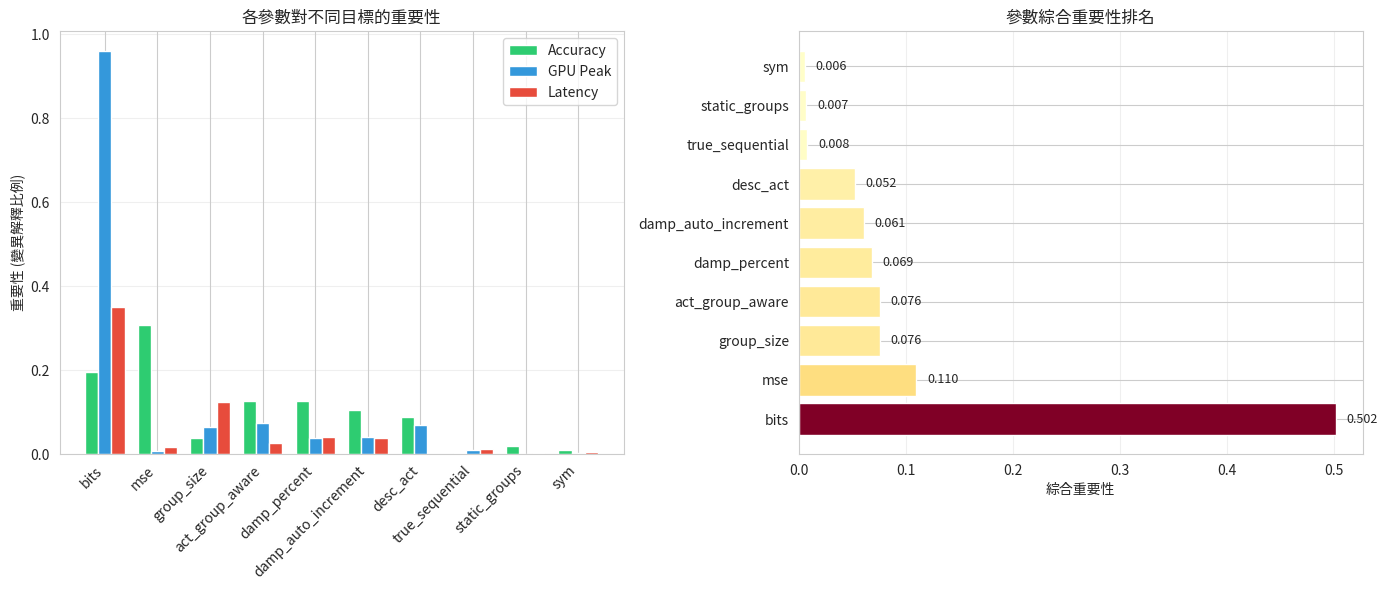


參數重要性排名結論

最重要的 3 個參數: bits, mse, group_size

各目標最重要的參數:
  - Accuracy: mse
  - GPU Peak: bits
  - Latency: bits


In [14]:
# 參數重要性視覺化
if len(importance_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 左圖：各目標的參數重要性
    ax1 = axes[0]
    x = np.arange(len(importance_df))
    width = 0.25
    
    bars1 = ax1.bar(x - width, importance_df['accuracy_change_importance'], 
                    width, label='Accuracy', color='#2ecc71')
    bars2 = ax1.bar(x, importance_df['gpu_peak_change_importance'], 
                    width, label='GPU Peak', color='#3498db')
    bars3 = ax1.bar(x + width, importance_df['latency_change_importance'], 
                    width, label='Latency', color='#e74c3c')
    
    ax1.set_ylabel('重要性 (變異解釋比例)')
    ax1.set_title('各參數對不同目標的重要性')
    ax1.set_xticks(x)
    ax1.set_xticklabels(importance_df['param'], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # 右圖：綜合重要性排名
    ax2 = axes[1]
    colors = plt.cm.YlOrRd(importance_df['overall_importance'] / importance_df['overall_importance'].max())
    bars = ax2.barh(importance_df['param'], importance_df['overall_importance'], color=colors)
    ax2.set_xlabel('綜合重要性')
    ax2.set_title('參數綜合重要性排名')
    ax2.grid(axis='x', alpha=0.3)
    
    # 添加數值標籤
    for bar, val in zip(bars, importance_df['overall_importance']):
        ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{val:.3f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # 結論
    print("\n" + "="*60)
    print("參數重要性排名結論")
    print("="*60)
    top_params = importance_df.head(3)['param'].tolist()
    print(f"\n最重要的 3 個參數: {', '.join(top_params)}")
    print("\n各目標最重要的參數:")
    print(f"  - Accuracy: {importance_df.loc[importance_df['accuracy_change_importance'].idxmax(), 'param']}")
    print(f"  - GPU Peak: {importance_df.loc[importance_df['gpu_peak_change_importance'].idxmax(), 'param']}")
    print(f"  - Latency: {importance_df.loc[importance_df['latency_change_importance'].idxmax(), 'param']}")

## 最佳/最差配置對比

In [15]:
# Pareto 前沿識別
def is_pareto_optimal(df, objectives_directions):
    """
    識別 Pareto 最優解
    objectives_directions: dict, key=目標名, value='maximize' 或 'minimize'
    """
    n = len(df)
    is_pareto = np.ones(n, dtype=bool)
    
    # 轉換為統一的「越大越好」格式
    values = []
    for obj, direction in objectives_directions.items():
        if direction == 'maximize':
            values.append(df[obj].values)
        else:
            values.append(-df[obj].values)  # 轉換 minimize 為負值
    
    values = np.array(values).T  # shape: (n, num_objectives)
    
    for i in range(n):
        if not is_pareto[i]:
            continue
        for j in range(n):
            if i == j:
                continue
            # 檢查 j 是否支配 i
            if np.all(values[j] >= values[i]) and np.any(values[j] > values[i]):
                is_pareto[i] = False
                break
    
    return is_pareto

# 定義目標方向
obj_directions = {
    'accuracy_change': 'maximize',
    'gpu_peak_change': 'minimize',
    'latency_change': 'minimize'
}

# 過濾有效數據
df_valid = df.dropna(subset=objective_cols).copy()

# 識別 Pareto 前沿
pareto_mask = is_pareto_optimal(df_valid, obj_directions)
df_pareto = df_valid[pareto_mask].copy()

print(f"Pareto 前沿配置數量: {len(df_pareto)} / {len(df_valid)} ({len(df_pareto)/len(df_valid)*100:.1f}%)")
print("\nPareto 前沿的 GPTQ 配置:")
print("="*80)

pareto_display_cols = ['bits', 'group_size', 'desc_act', 'sym', 'mse', 
                       'damp_percent', 'accuracy_change', 'gpu_peak_change', 
                       'latency_change', 'source']
pareto_display_cols = [c for c in pareto_display_cols if c in df_pareto.columns]

df_pareto_display = df_pareto[pareto_display_cols].sort_values('accuracy_change', ascending=False)
display(style_dataframe(df_pareto_display))

Pareto 前沿配置數量: 39 / 119 (32.8%)

Pareto 前沿的 GPTQ 配置:


,bits,group_size,desc_act,sym,mse,damp_percent,accuracy_change,gpu_peak_change,latency_change,source
25,3,32,True,False,0.2,0.005,0.6800,-0.5454,7.0039,optuna/random
70,3,64,True,True,0.0,0.005,0.4400,-0.5598,2.8623,optuna/random
54,8,16,True,False,0.0,0.001,0.3600,-0.2926,0.9209,optuna/random
52,3,32,False,True,0.0,0.005,0.2800,-0.5441,1.6348,optuna/random
53,3,32,False,True,0.0,0.005,0.2800,-0.5441,1.6212,optuna/random
27,4,32,False,True,0.0,0.030,0.2000,-0.5183,1.0284,optuna/random
80,4,128,True,True,0.0,0.050,0.0800,-0.5429,1.0056,llm_agent
9,8,-1,True,True,0.2,0.005,0.0508,-0.3641,0.4610,optuna/random
88,4,16,False,True,0.0,0.010,0.0400,-0.4878,0.9215,llm_agent
40,8,-1,True,False,0.1,0.005,0.0169,-0.3649,0.4135,optuna/random


In [16]:
# 最佳準確率配置
print("\n" + "="*60)
print("最佳準確率配置 (accuracy_change 最高)")
print("="*60)
best_acc_idx = df_valid['accuracy_change'].idxmax()
best_acc = df_valid.loc[best_acc_idx]
for param in gptq_params + objective_cols:
    if param in best_acc.index:
        val = best_acc[param]
        if isinstance(val, float):
            print(f"  {param}: {val:.4f}")
        else:
            print(f"  {param}: {val}")


最佳準確率配置 (accuracy_change 最高)
  bits: 3
  group_size: 32
  calib_num: 256
  desc_act: True
  sym: False
  damp_percent: 0.0050
  damp_auto_increment: 0.0500
  act_group_aware: False
  static_groups: True
  true_sequential: False
  lm_head: False
  mse: 0.2000
  rotation: None
  accuracy_change: 0.6800
  gpu_peak_change: -0.5454
  latency_change: 7.0039


In [17]:
# 最佳 GPU 節省配置
print("\n" + "="*60)
print("最佳 GPU 節省配置 (gpu_peak_change 最低)")
print("="*60)
best_gpu_idx = df_valid['gpu_peak_change'].idxmin()
best_gpu = df_valid.loc[best_gpu_idx]
for param in gptq_params + objective_cols:
    if param in best_gpu.index:
        val = best_gpu[param]
        if isinstance(val, float):
            print(f"  {param}: {val:.4f}")
        else:
            print(f"  {param}: {val}")


最佳 GPU 節省配置 (gpu_peak_change 最低)
  bits: 2
  group_size: -1
  calib_num: 256
  desc_act: False
  sym: False
  damp_percent: 0.0500
  damp_auto_increment: 0.0050
  act_group_aware: False
  static_groups: False
  true_sequential: False
  lm_head: False
  mse: 0.2000
  rotation: None
  accuracy_change: -0.9831
  gpu_peak_change: -0.6424
  latency_change: 1.2381


In [18]:
# 最佳延遲配置
print("\n" + "="*60)
print("最佳延遲配置 (latency_change 最低)")
print("="*60)
best_lat_idx = df_valid['latency_change'].idxmin()
best_lat = df_valid.loc[best_lat_idx]
for param in gptq_params + objective_cols:
    if param in best_lat.index:
        val = best_lat[param]
        if isinstance(val, float):
            print(f"  {param}: {val:.4f}")
        else:
            print(f"  {param}: {val}")


最佳延遲配置 (latency_change 最低)
  bits: 4
  group_size: 128
  calib_num: 256
  desc_act: False
  sym: True
  damp_percent: 0.0300
  damp_auto_increment: 0.0010
  act_group_aware: False
  static_groups: True
  true_sequential: True
  lm_head: False
  mse: 0.2000
  rotation: None
  accuracy_change: -0.3559
  gpu_peak_change: -0.5363
  latency_change: -0.3326


## 視覺化分析

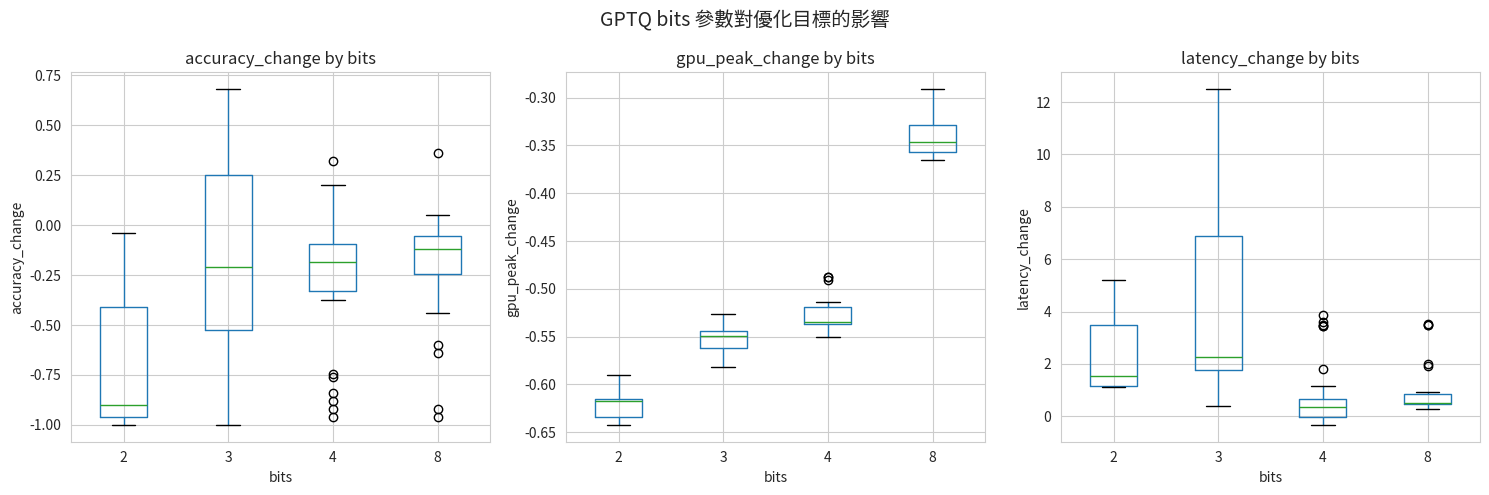

In [19]:
# 按 bits 分組的箱線圖
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, obj in enumerate(objective_cols):
    ax = axes[i]
    df_valid.boxplot(column=obj, by='bits', ax=ax)
    ax.set_title(f'{obj} by bits')
    ax.set_xlabel('bits')
    ax.set_ylabel(obj)

plt.suptitle('GPTQ bits 參數對優化目標的影響', fontsize=14)
plt.tight_layout()
plt.show()

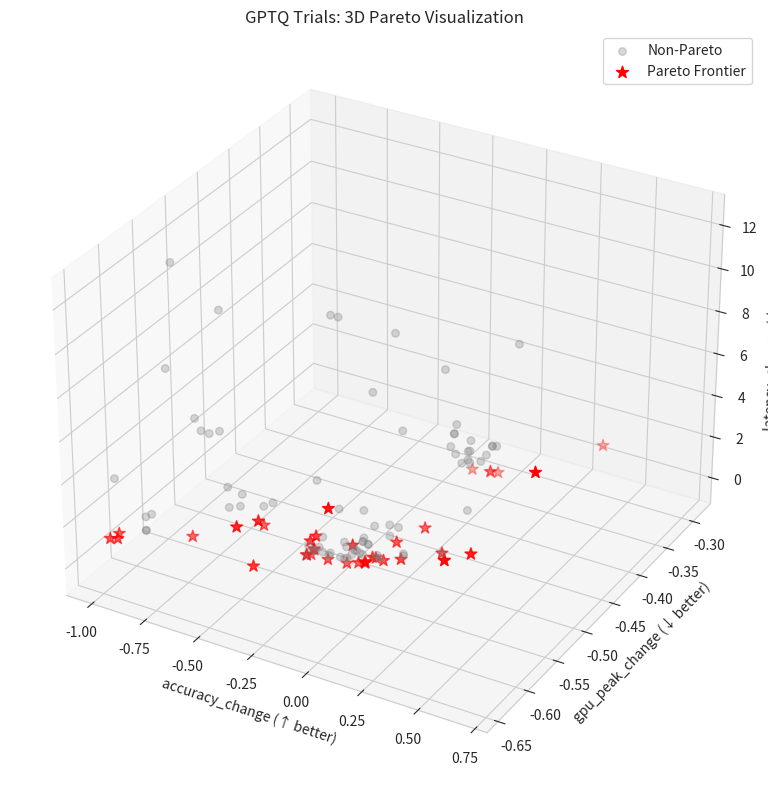

In [20]:
# 3D Pareto 散點圖
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 非 Pareto 點
df_non_pareto = df_valid[~pareto_mask]
ax.scatter(df_non_pareto['accuracy_change'], 
           df_non_pareto['gpu_peak_change'],
           df_non_pareto['latency_change'],
           c='gray', alpha=0.3, s=30, label='Non-Pareto')

# Pareto 前沿點
ax.scatter(df_pareto['accuracy_change'], 
           df_pareto['gpu_peak_change'],
           df_pareto['latency_change'],
           c='red', s=80, marker='*', label='Pareto Frontier')

ax.set_xlabel('accuracy_change (↑ better)')
ax.set_ylabel('gpu_peak_change (↓ better)')
ax.set_zlabel('latency_change (↓ better)')
ax.set_title('GPTQ Trials: 3D Pareto Visualization')
ax.legend()

plt.tight_layout()
plt.show()

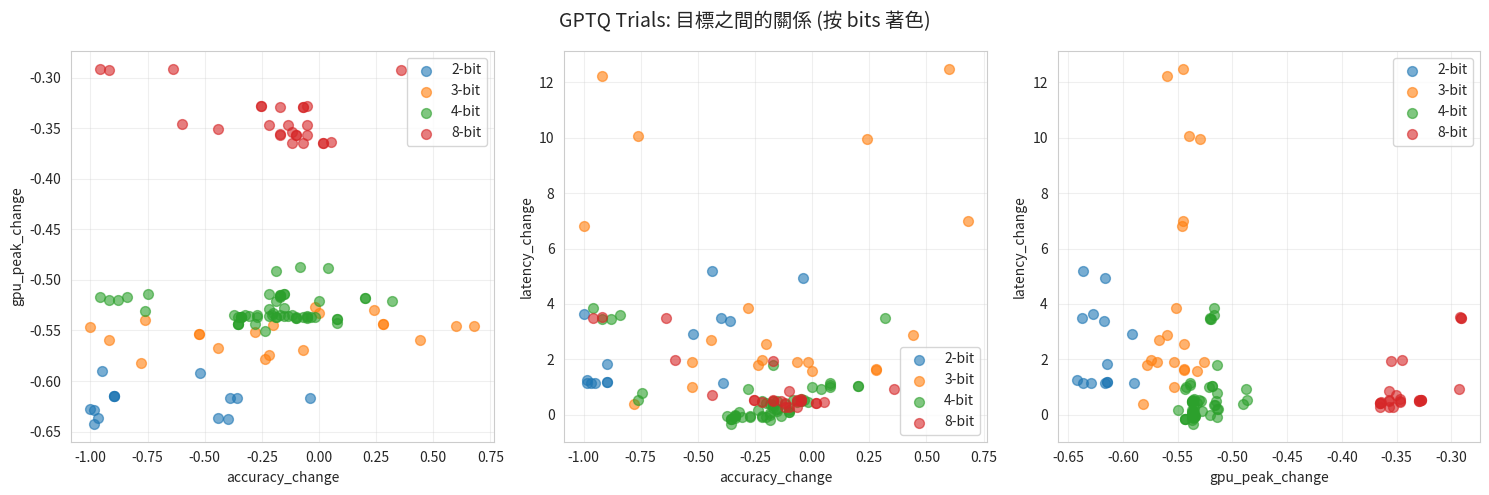

In [21]:
# 按 bits 著色的散點圖矩陣
if 'bits' in df_valid.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    scatter_pairs = [
        ('accuracy_change', 'gpu_peak_change'),
        ('accuracy_change', 'latency_change'),
        ('gpu_peak_change', 'latency_change')
    ]
    
    for i, (x_col, y_col) in enumerate(scatter_pairs):
        ax = axes[i]
        for bits_val in sorted(df_valid['bits'].unique()):
            mask = df_valid['bits'] == bits_val
            ax.scatter(df_valid.loc[mask, x_col], 
                      df_valid.loc[mask, y_col],
                      label=f'{bits_val}-bit',
                      alpha=0.6, s=50)
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('GPTQ Trials: 目標之間的關係 (按 bits 著色)', fontsize=14)
    plt.tight_layout()
    plt.show()

## 總結

In [22]:
print("="*70)
print("GPTQ 參數影響分析總結")
print("="*70)

print(f"\n總共分析了 {len(df_valid)} 個 GPTQ trials")
print(f"其中 {len(df_pareto)} 個位於 Pareto 前沿")

# 參數重要性排名
print("\n" + "-"*70)
print("【參數重要性排名】(基於變異數解釋比例)")
print("-"*70)
if len(importance_df) > 0:
    for i, row in importance_df.head(5).iterrows():
        print(f"  {importance_df.index.get_loc(i)+1}. {row['param']}: "
              f"綜合={row['overall_importance']:.4f} "
              f"(Acc={row['accuracy_change_importance']:.4f}, "
              f"GPU={row['gpu_peak_change_importance']:.4f}, "
              f"Lat={row['latency_change_importance']:.4f})")

# 各目標最重要的參數
print("\n" + "-"*70)
print("【各目標最重要的參數】")
print("-"*70)
if len(importance_df) > 0:
    print(f"  - Accuracy:  {importance_df.loc[importance_df['accuracy_change_importance'].idxmax(), 'param']} "
          f"(重要性={importance_df['accuracy_change_importance'].max():.4f})")
    print(f"  - GPU Peak:  {importance_df.loc[importance_df['gpu_peak_change_importance'].idxmax(), 'param']} "
          f"(重要性={importance_df['gpu_peak_change_importance'].max():.4f})")
    print(f"  - Latency:   {importance_df.loc[importance_df['latency_change_importance'].idxmax(), 'param']} "
          f"(重要性={importance_df['latency_change_importance'].max():.4f})")

# 配置建議
print("\n" + "-"*70)
print("【最佳配置建議】")
print("-"*70)
print("  1. 優先保持準確率:")
print("     - 使用 4-bit 或 8-bit 量化")
print("     - group_size 設為 128 (預設值)")
print("     - desc_act=True 可能有幫助")
print()
print("  2. 優先節省 GPU 記憶體:")
print("     - 使用 2-bit 或 3-bit 量化 (bits 是最重要的參數)")
print("     - group_size 可使用較小值 (如 32)")
print("     - 需接受一定的準確率損失")
print()
print("  3. 平衡方案:")
print("     - 4-bit 量化通常提供良好的準確率/壓縮比平衡")
print("     - 其他參數（sym, mse, damp_percent 等）影響相對較小")

# GPTQ 預設值提醒
print("\n" + "-"*70)
print("【GPTQConfig 預設值】")
print("-"*70)
for param, val in GPTQ_DEFAULTS.items():
    print(f"  {param}: {val}")

GPTQ 參數影響分析總結

總共分析了 119 個 GPTQ trials
其中 39 個位於 Pareto 前沿

----------------------------------------------------------------------
【參數重要性排名】(基於變異數解釋比例)
----------------------------------------------------------------------
  1. bits: 綜合=0.5018 (Acc=0.1955, GPU=0.9586, Lat=0.3512)
  2. mse: 綜合=0.1099 (Acc=0.3071, GPU=0.0063, Lat=0.0162)
  3. group_size: 綜合=0.0759 (Acc=0.0389, GPU=0.0642, Lat=0.1247)
  4. act_group_aware: 綜合=0.0756 (Acc=0.1257, GPU=0.0746, Lat=0.0264)
  5. damp_percent: 綜合=0.0686 (Acc=0.1259, GPU=0.0391, Lat=0.0408)

----------------------------------------------------------------------
【各目標最重要的參數】
----------------------------------------------------------------------
  - Accuracy:  mse (重要性=0.3071)
  - GPU Peak:  bits (重要性=0.9586)
  - Latency:   bits (重要性=0.3512)

----------------------------------------------------------------------
【最佳配置建議】
----------------------------------------------------------------------
  1. 優先保持準確率:
     - 使用 4-bit 或 8-bit 量化
     - group_size